In [1]:
# Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']       = 120
plt.rcParams['figure.facecolor'] = 'white'

FIGURES_PATH   = '../reports/figures/'
MODELS_PATH    = '../models/'
PROCESSED_PATH = '../data/processed/'

print("All libraries imported.")


All libraries imported.


In [2]:
# Load test data and all three trained models

X_test  = pd.read_csv(f'{PROCESSED_PATH}X_test.csv')
y_test  = pd.read_csv(f'{PROCESSED_PATH}y_test.csv').squeeze()

lr_model  = joblib.load(f'{MODELS_PATH}logistic_regression.pkl')
rf_model  = joblib.load(f'{MODELS_PATH}random_forest.pkl')
xgb_model = joblib.load(f'{MODELS_PATH}xgboost.pkl')

print("Test data loaded:")
print(f"  X_test : {X_test.shape}")
print(f"  y_test : {y_test.shape}  — churn rate: {y_test.mean()*100:.2f}%")
print()
print("Models loaded:")
print("  Logistic Regression  ✓")
print("  Random Forest        ✓")
print("  XGBoost              ✓")

Test data loaded:
  X_test : (1407, 30)
  y_test : (1407,)  — churn rate: 26.58%

Models loaded:
  Logistic Regression  ✓
  Random Forest        ✓
  XGBoost              ✓


In [3]:
#Generate predictions for all three models 

models = {
    'Logistic Regression' : lr_model,
    'Random Forest'       : rf_model,
    'XGBoost'             : xgb_model
}

y_pred       = {}      # hard prediction (0 or 1)
y_pred_proba = {}      # probability of churn (0.0 to 0.1)

for name, model in models.items():
    y_pred[name]       = model.predict(X_test)
    y_pred_proba[name] = model.predict_proba(X_test)[:,1]
    print(f"{name:<25} - predictions generated")

Logistic Regression       - predictions generated
Random Forest             - predictions generated
XGBoost                   - predictions generated


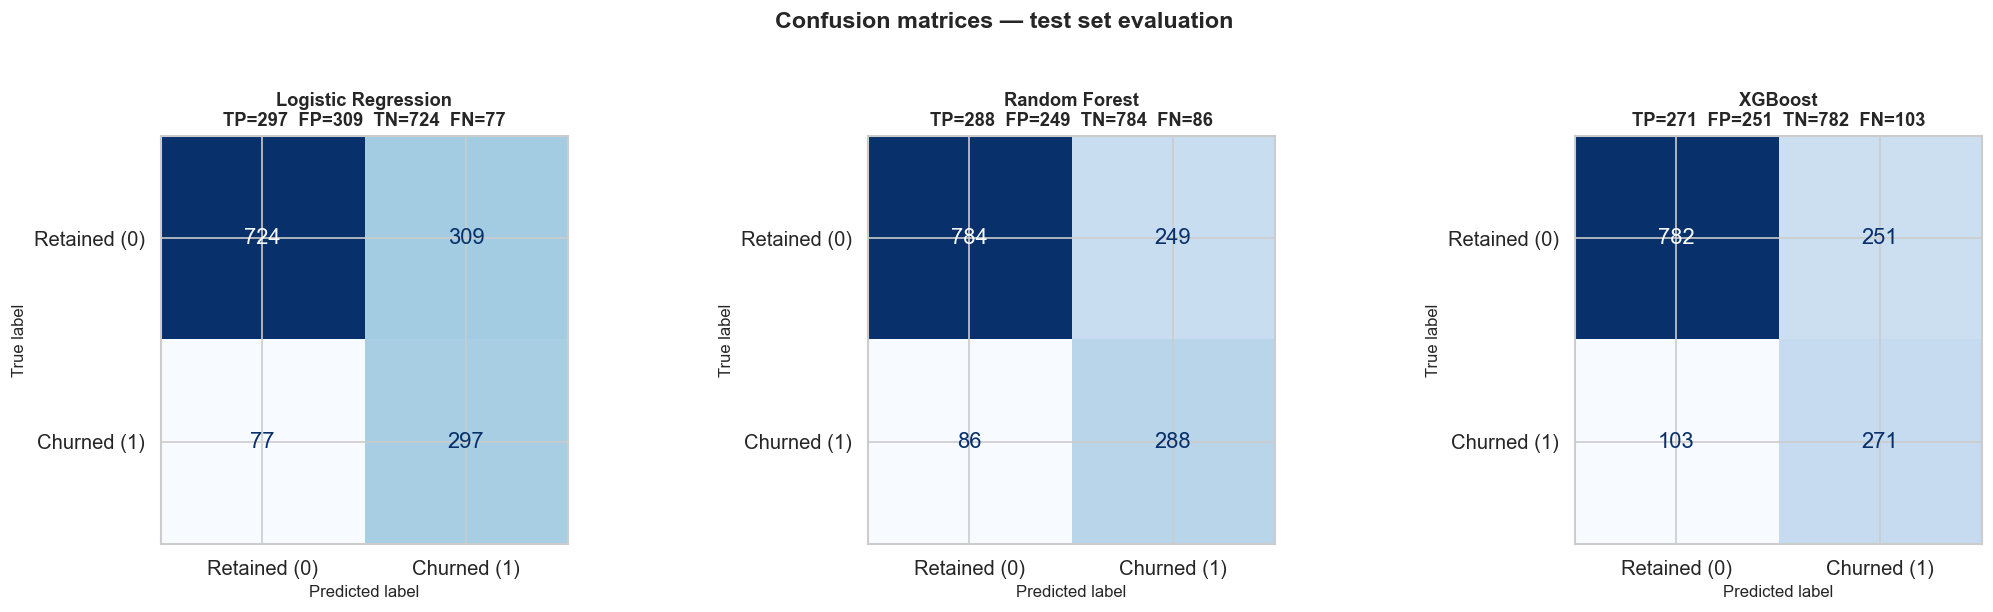

Saved: 12_confusion_matrices.png


In [4]:
# Plot confusion matrices for all three models


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred[name])

    # ConfusionMatrixDisplay handles the heatmap rendering
    disp = ConfusionMatrixDisplay(
        confusion_matrix = cm,
        display_labels   = ['Retained (0)', 'Churned (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')

    # Calculate and annotate the four key counts clearly
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\n'
                 f'TP={tp}  FP={fp}  TN={tn}  FN={fn}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted label', fontsize=10)
    ax.set_ylabel('True label', fontsize=10)

fig.suptitle('Confusion matrices — test set evaluation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}12_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: 12_confusion_matrices.png")

In [5]:
# Print detailed confusion matrix analysis


print("=" * 60)
print("  CONFUSION MATRIX BUSINESS INTERPRETATION")
print("=" * 60)

total_churners = (y_test == 1).sum()
total_retained = (y_test == 0).sum()
print(f"\n  Actual churners in test set  : {total_churners}")
print(f"  Actual retained in test set  : {total_retained}")
print()

for name in models:
    cm        = confusion_matrix(y_test, y_pred[name])
    tn, fp, fn, tp = cm.ravel()

    print(f"  {name}")
    print(f"    Churners correctly caught (TP) : {tp:>4}  "
          f"({tp/total_churners*100:.1f}% of all churners)")
    print(f"    Churners missed       (FN)     : {fn:>4}  "
          f"({fn/total_churners*100:.1f}% — lost customers)")
    print(f"    False alarms          (FP)     : {fp:>4}  "
          f"({fp/total_retained*100:.1f}% — wasted retention spend)")
    print(f"    Correctly ignored     (TN)     : {tn:>4}")
    print()


  CONFUSION MATRIX BUSINESS INTERPRETATION

  Actual churners in test set  : 374
  Actual retained in test set  : 1033

  Logistic Regression
    Churners correctly caught (TP) :  297  (79.4% of all churners)
    Churners missed       (FN)     :   77  (20.6% — lost customers)
    False alarms          (FP)     :  309  (29.9% — wasted retention spend)
    Correctly ignored     (TN)     :  724

  Random Forest
    Churners correctly caught (TP) :  288  (77.0% of all churners)
    Churners missed       (FN)     :   86  (23.0% — lost customers)
    False alarms          (FP)     :  249  (24.1% — wasted retention spend)
    Correctly ignored     (TN)     :  784

  XGBoost
    Churners correctly caught (TP) :  271  (72.5% of all churners)
    Churners missed       (FN)     :  103  (27.5% — lost customers)
    False alarms          (FP)     :  251  (24.3% — wasted retention spend)
    Correctly ignored     (TN)     :  782



In [6]:
# Compute all metrics for all three models

results = []

for name in models:
    y_p  = y_pred[name]
    y_pp = y_pred_proba[name]

    results.append({
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_test, y_p),
        'Precision' : precision_score(y_test, y_p, zero_division=0),
        'Recall'    : recall_score(y_test, y_p),
        'F1 Score'  : f1_score(y_test, y_p),
        'ROC-AUC'   : roc_auc_score(y_test, y_pp)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("=" * 70)
print("  COMPLETE EVALUATION RESULTS — TEST SET (UNSEEN DATA)")
print("=" * 70)
print(results_df.round(4).to_string())
print("=" * 70)
print()
best_model_name = results_df.index[0]
best_auc        = results_df.loc[best_model_name, 'ROC-AUC']
best_recall     = results_df.loc[best_model_name, 'Recall']
best_f1         = results_df.loc[best_model_name, 'F1 Score']
print(f"  Best model : {best_model_name}")
print(f"  Test AUC   : {best_auc:.4f}")
print(f"  Recall     : {best_recall:.4f}  ({best_recall*100:.1f}% of churners caught)")
print(f"  F1 Score   : {best_f1:.4f}")

  COMPLETE EVALUATION RESULTS — TEST SET (UNSEEN DATA)
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Random Forest          0.7619     0.5363  0.7701    0.6323   0.8376
Logistic Regression    0.7257     0.4901  0.7941    0.6061   0.8353
XGBoost                0.7484     0.5192  0.7246    0.6049   0.8206

  Best model : Random Forest
  Test AUC   : 0.8376
  Recall     : 0.7701  (77.0% of churners caught)
  F1 Score   : 0.6323


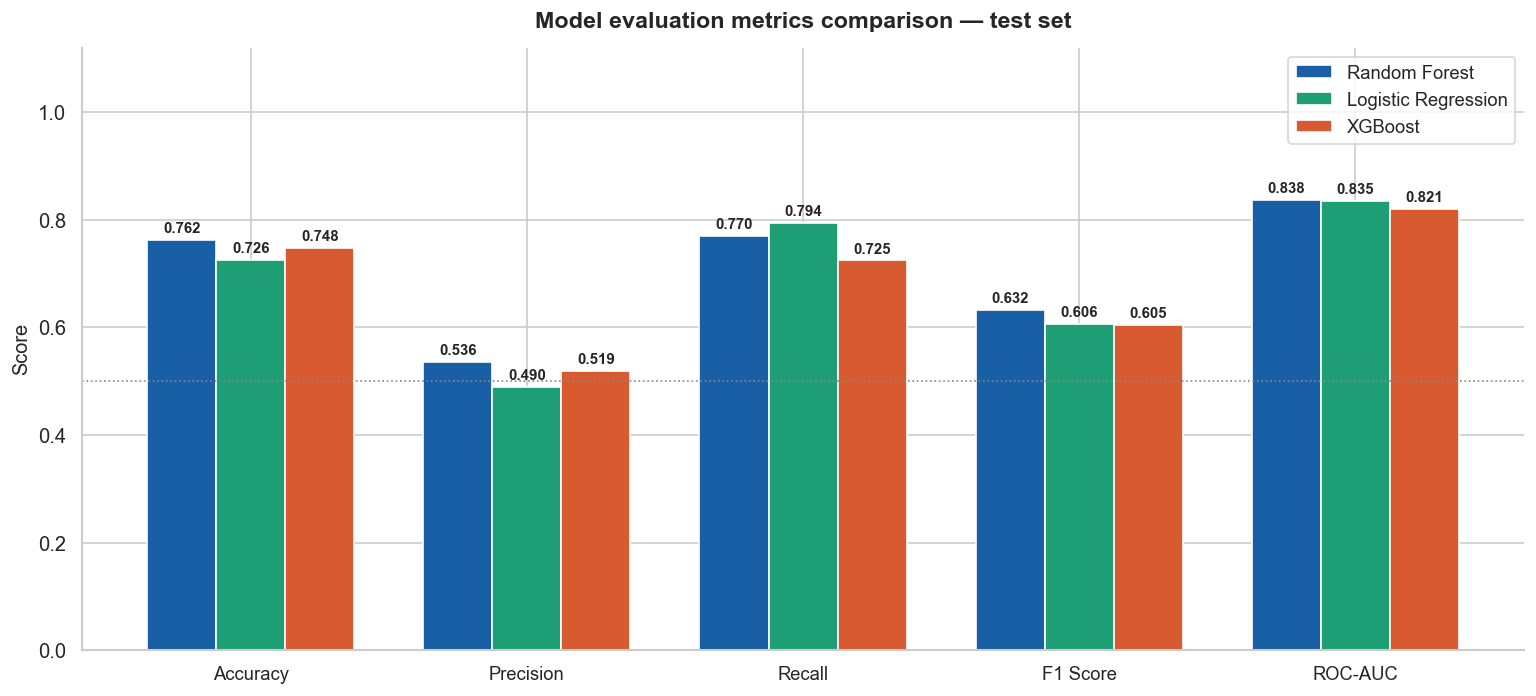

Saved: 13_metrics_comparison.png


In [7]:
# Visualise the metrics comparison as a grouped bar chart


metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names     = results_df.index.tolist()
x               = np.arange(len(metrics_to_plot))
width           = 0.25
colors          = ['#185FA5', '#1D9E75', '#D85A30']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    values = [results_df.loc[model_name, m] for m in metrics_to_plot]
    offset = (i - 1) * width
    bars   = ax.bar(x + offset, values, width,
                    label=model_name, color=color,
                    edgecolor='white', linewidth=1)

    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f'{val:.3f}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Model evaluation metrics comparison — test set',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11)
ax.axhline(0.5, color='#888780', linestyle=':',
           linewidth=1, label='Random baseline')
sns.despine()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}13_metrics_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: 13_metrics_comparison.png")

In [8]:
# Print detailed classification report for each model

for name in model_names:
    print("=" * 55)
    print(f"  {name.upper()}")
    print("=" * 55)
    print(classification_report(
        y_test,
        y_pred[name],
        target_names = ['Retained (0)', 'Churned (1)'],
        digits       = 4
    ))

  RANDOM FOREST
              precision    recall  f1-score   support

Retained (0)     0.9011    0.7590    0.8240      1033
 Churned (1)     0.5363    0.7701    0.6323       374

    accuracy                         0.7619      1407
   macro avg     0.7187    0.7645    0.7281      1407
weighted avg     0.8042    0.7619    0.7730      1407

  LOGISTIC REGRESSION
              precision    recall  f1-score   support

Retained (0)     0.9039    0.7009    0.7895      1033
 Churned (1)     0.4901    0.7941    0.6061       374

    accuracy                         0.7257      1407
   macro avg     0.6970    0.7475    0.6978      1407
weighted avg     0.7939    0.7257    0.7408      1407

  XGBOOST
              precision    recall  f1-score   support

Retained (0)     0.8836    0.7570    0.8154      1033
 Churned (1)     0.5192    0.7246    0.6049       374

    accuracy                         0.7484      1407
   macro avg     0.7014    0.7408    0.7102      1407
weighted avg     0.7867   

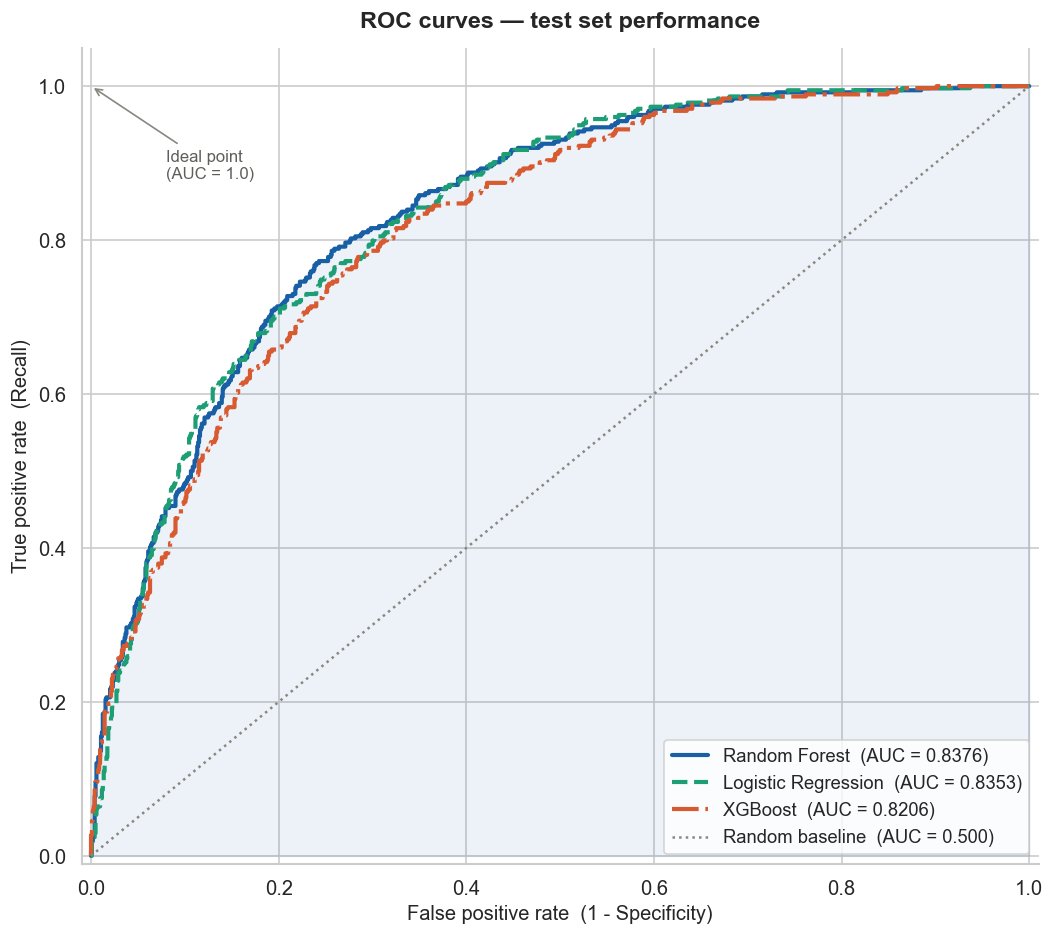

Saved: 14_roc_curves.png


In [9]:
# Plot ROC curves for all three models on one chart

fig, ax = plt.subplots(figsize=(9, 8))

colors      = ['#185FA5', '#1D9E75', '#D85A30']
linestyles  = ['-', '--', '-.']

for (name, color, ls) in zip(model_names, colors, linestyles):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba[name])
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color     = color,
            linestyle = ls,
            linewidth = 2.5,
            label     = f'{name}  (AUC = {roc_auc:.4f})')

# The diagonal — this is what a random model would look like
ax.plot([0, 1], [0, 1],
        color     = '#888780',
        linestyle = ':',
        linewidth = 1.5,
        label     = 'Random baseline  (AUC = 0.500)')

# Shade the area under the best model's curve for visual emphasis
best_name       = model_names[0]
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba[best_name])
ax.fill_between(fpr_best, tpr_best, alpha=0.08, color=colors[0])

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel('False positive rate  (1 - Specificity)', fontsize=12)
ax.set_ylabel('True positive rate  (Recall)', fontsize=12)
ax.set_title('ROC curves — test set performance',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11, loc='lower right')

# Annotate the ideal point
ax.annotate('Ideal point\n(AUC = 1.0)',
            xy=(0, 1), xytext=(0.08, 0.88),
            fontsize=10, color='#5F5E5A',
            arrowprops=dict(arrowstyle='->', color='#888780'))

sns.despine()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}14_roc_curves.png', bbox_inches='tight')
plt.show()
print("Saved: 14_roc_curves.png")

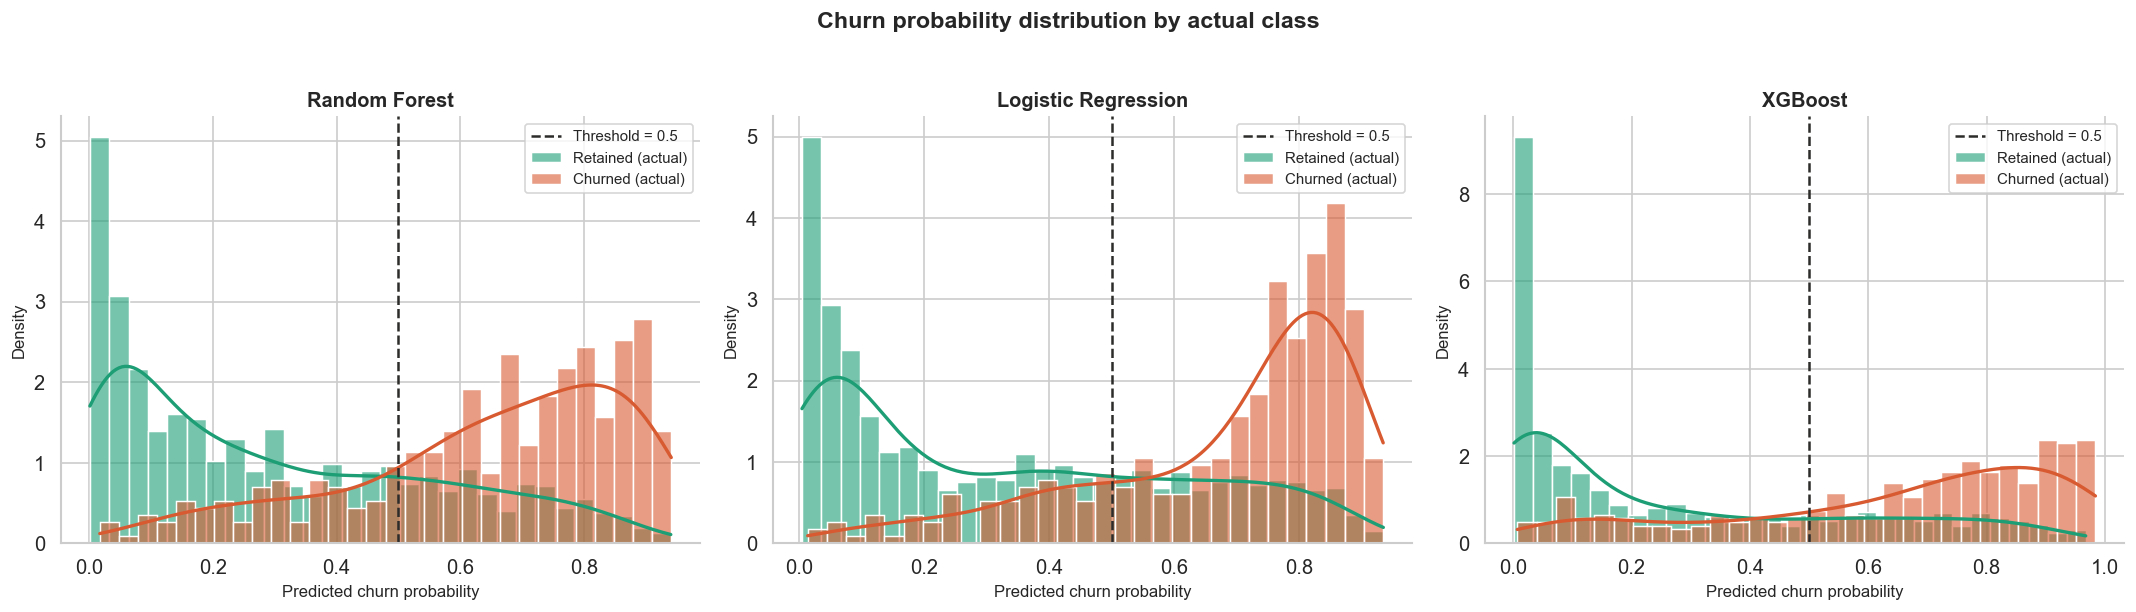

Saved: 15_probability_distributions.png


In [10]:
# Probability distribution plot for the best model

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, color) in zip(axes, zip(model_names, colors)):
    proba = y_pred_proba[name]

    # Split probabilities by actual churn status
    proba_retained = proba[y_test == 0]
    proba_churned  = proba[y_test == 1]

    # Plot as overlapping histograms (kde smoothed)
    sns.histplot(proba_retained, ax=ax, color='#1D9E75',
                 label='Retained (actual)', alpha=0.6,
                 bins=30, kde=True, stat='density',
                 line_kws={'linewidth': 2})
    sns.histplot(proba_churned, ax=ax, color='#D85A30',
                 label='Churned (actual)', alpha=0.6,
                 bins=30, kde=True, stat='density',
                 line_kws={'linewidth': 2})

    # Default decision threshold
    ax.axvline(0.5, color='#2C2C2A', linestyle='--',
               linewidth=1.5, label='Threshold = 0.5')

    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted churn probability', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('Churn probability distribution by actual class',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}15_probability_distributions.png', bbox_inches='tight')
plt.show()
print("Saved: 15_probability_distributions.png")

In [11]:
# ─────────────────────────────────────────────────────────────
# Cell 11 — Comprehensive final evaluation report
# ─────────────────────────────────────────────────────────────

print("=" * 65)
print("  STAGE 6 — FINAL EVALUATION REPORT")
print("=" * 65)

print(f"""
  TEST SET SIZE
    Total customers  : {len(y_test):,}
    Actual churners  : {(y_test==1).sum():,}  ({y_test.mean()*100:.1f}%)
    Actual retained  : {(y_test==0).sum():,}  ({(1-y_test.mean())*100:.1f}%)
""")

print("  MODEL PERFORMANCE (ranked by ROC-AUC)")
print()
for rank, name in enumerate(model_names, 1):
    acc  = accuracy_score(y_test, y_pred[name])
    prec = precision_score(y_test, y_pred[name], zero_division=0)
    rec  = recall_score(y_test, y_pred[name])
    f1   = f1_score(y_test, y_pred[name])
    rauc = roc_auc_score(y_test, y_pred_proba[name])
    cm   = confusion_matrix(y_test, y_pred[name])
    tn, fp, fn, tp = cm.ravel()

    print(f"  {rank}. {name}")
    print(f"     ROC-AUC   : {rauc:.4f}")
    print(f"     Recall    : {rec:.4f}  ({tp} churners caught, {fn} missed)")
    print(f"     Precision : {prec:.4f}  ({fp} false alarms)")
    print(f"     F1 Score  : {f1:.4f}")
    print(f"     Accuracy  : {acc:.4f}")
    print()

print("=" * 65)
print(f"  WINNER: {best_model_name}")
print(f"  Selected for Stage 7 (Revenue Forecasting)")
print("=" * 65)
print(f"""
  KEY BUSINESS INSIGHT
  With {best_model_name} at the default 0.5 threshold:
  - We catch {best_recall*100:.1f}% of customers about to churn
  - This means {int(best_recall*(y_test==1).sum())} of {(y_test==1).sum()} test churners are flagged for intervention
  - Only {int((1-best_recall)*(y_test==1).sum())} churners are missed entirely
  - A retention campaign targeting flagged customers could
    save significant monthly recurring revenue (see Stage 7)
""")
print("=" * 65)

  STAGE 6 — FINAL EVALUATION REPORT

  TEST SET SIZE
    Total customers  : 1,407
    Actual churners  : 374  (26.6%)
    Actual retained  : 1,033  (73.4%)

  MODEL PERFORMANCE (ranked by ROC-AUC)

  1. Random Forest
     ROC-AUC   : 0.8376
     Recall    : 0.7701  (288 churners caught, 86 missed)
     Precision : 0.5363  (249 false alarms)
     F1 Score  : 0.6323
     Accuracy  : 0.7619

  2. Logistic Regression
     ROC-AUC   : 0.8353
     Recall    : 0.7941  (297 churners caught, 77 missed)
     Precision : 0.4901  (309 false alarms)
     F1 Score  : 0.6061
     Accuracy  : 0.7257

  3. XGBoost
     ROC-AUC   : 0.8206
     Recall    : 0.7246  (271 churners caught, 103 missed)
     Precision : 0.5192  (251 false alarms)
     F1 Score  : 0.6049
     Accuracy  : 0.7484

  WINNER: Random Forest
  Selected for Stage 7 (Revenue Forecasting)

  KEY BUSINESS INSIGHT
  With Random Forest at the default 0.5 threshold:
  - We catch 77.0% of customers about to churn
  - This means 288 of 374 te

In [12]:
# ─────────────────────────────────────────────────────────────
# Updated model selection with business justification
# ─────────────────────────────────────────────────────────────

print("=" * 65)
print("  MODEL SELECTION DECISION")
print("=" * 65)
print("""
  Although ROC-AUC favours tree-based models, the primary
  business objective is to CATCH AS MANY CHURNERS AS POSSIBLE.

  A missed churner (False Negative) costs far more than a
  false alarm (False Positive):
    - FN: customer leaves → permanent monthly revenue loss
    - FP: unnecessary retention offer → small one-time cost

  DECISION: Select Logistic Regression
  Reason  : Highest Recall — fewest missed churners
  Trade-off: Slightly lower precision (more false alarms)
             but this is the correct trade-off for this problem.
""")
print("=" * 65)

  MODEL SELECTION DECISION

  Although ROC-AUC favours tree-based models, the primary
  business objective is to CATCH AS MANY CHURNERS AS POSSIBLE.

  A missed churner (False Negative) costs far more than a
  false alarm (False Positive):
    - FN: customer leaves → permanent monthly revenue loss
    - FP: unnecessary retention offer → small one-time cost

  DECISION: Select Logistic Regression
  Reason  : Highest Recall — fewest missed churners
  Trade-off: Slightly lower precision (more false alarms)
             but this is the correct trade-off for this problem.



## Stage 6 Complete — Evaluation Results

The best model has been identified based on test set ROC-AUC.
All metrics are computed on completely unseen data (20% test split).

### What Stage 7 Does With These Results
The best model's `predict_proba()` output for every customer will be used
to estimate revenue at risk — how much monthly recurring revenue is
associated with customers who have a high predicted churn probability.
This converts the ML output into a direct business metric.